In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
import bagpipes as pipes
from bagpipes import model_galaxy 
import copy
os.chdir("/Users/christine/FA26_1501")

model_components = {}
model_components["redshift"] = 0 # Observed redshift (mandatory)
model_components["veldisp"] = 300 # Max age of birth clouds: Gyr
model_components["t_bc"] = 0.01


# Dict containing SFH info
dblplaw = {}
dblplaw["tau"] = 12
dblplaw["alpha"] = 30
dblplaw["beta"] = 0.5
dblplaw["metallicity"] = 0.8
dblplaw["massformed"] = 11
model_components["dblplaw"] = dblplaw

dust = {}
dust["type"] = "Calzetti" #attenuation law
dust["Av"] = 0.2
dust["eta"] = 3
model_components["dust"] = dust

nebular = {}
nebular["logU"] = -3
model_components["nebular"] = nebular

uvista_filt_list = ["filters/CFHT_MegaCam.u.dat",
                    "filters/CFHT_MegaCam.g.dat",
                    "filters/CFHT_MegaCam.r.dat",
                    "filters/CFHT_MegaCam.i.dat",
                    "filters/CFHT_MegaCam.z.dat",
                    "filters/Subaru_Suprime.z.dat",
                    "filters/Paranal_VISTA.Y.dat",
                    "filters/Paranal_VISTA.J.dat",
                    "filters/Paranal_VISTA.H.dat",
                    "filters/Paranal_VISTA.Ks.dat",
                    "filters/Spitzer_IRAC.I1.dat",
                    "filters/Spitzer_IRAC.I2.dat"]

In [3]:
wavelength_grid = np.arange(2000, 7005, 5) # units A
model = model_galaxy(model_components, filt_list=uvista_filt_list)

F_true = model.photometry
Av_true = 0.2

sigma = 0.05*F_true
rng = np.random.default_rng(42)
F_obs = F_true + rng.normal(0, sigma)
print(F_obs / F_true - 1)

[ 0.01523585 -0.05199921  0.03752256  0.04702824 -0.09755176 -0.06510898
  0.00639202 -0.01581213 -0.00084006 -0.0426522   0.0439699   0.0388896 ]


In [4]:
results = {}

for step in [101, 401]:
    Av_grid = np.linspace(0,4, step) #this spacing should be finer than 0.05
    chi2 = np.zeros(len(Av_grid))
    for i, Av in enumerate(Av_grid):
        comps = copy.deepcopy(model_components)
        comps['dust']['Av'] = Av
        m = model_galaxy(comps, filt_list = uvista_filt_list)
        chi2[i] = np.sum(((F_obs - m.photometry)/sigma)**2)
    results[step] = (Av_grid, np.array(chi2))



In [5]:
for step in [101, 401]:
    Av_grid, chi2 = results[step]
    print(step, Av_grid[np.argmin(chi2)], chi2.min())

101 0.2 10.347088058561
401 0.21 10.002167901855373


Text(0, 0.5, '$\\Delta\\chi^2$')

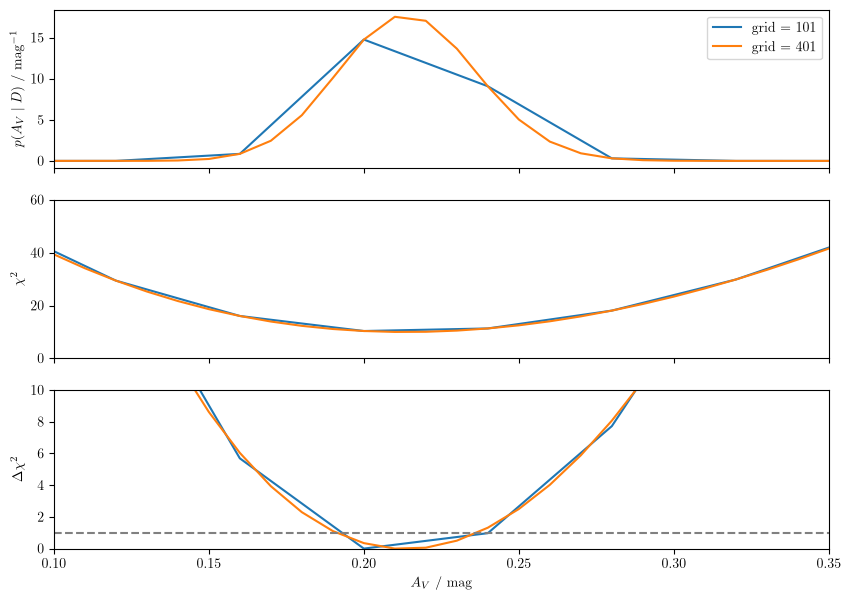

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=1, nrows=3, figsize = (10, 7), sharex = True)
for step in [101, 401]:
    Av_grid, chi2 = results[step]
    post = np.exp(-0.5*(chi2 - chi2.min()))
    post = post / np.trapezoid(post, Av_grid)

    delta = chi2 - chi2.min()
    ax1.plot(Av_grid, post, label = f'grid = {step}')
    ax2.plot(Av_grid, chi2)
    ax3.plot(Av_grid, delta)
ax1.set_xlim(0.1, 0.35)

ax1.set_ylabel(r"$p(A_V \mid D)$ / mag$^{-1}$")

ax2.set_ylim(0, 60)
ax2.set_ylabel(r'$\chi^2$')
ax1.legend()
ax3.axhline(1, color = "grey", linestyle = '--')
ax3.set_ylim(0,10)
ax3.set_xlabel(r"$A_V$ / mag")
ax3.set_ylabel(r"$\Delta\chi^2$")

In [16]:
Av_grid, chi2 = results[401]
post = np.exp(-0.5 * (chi2 - chi2.min()))
post = post / np.trapezoid(post, Av_grid)

In [17]:
dAv = Av_grid[1] - Av_grid[0]
cdf = np.cumsum(post) * dAv
cdf = cdf / cdf[-1]

In [18]:
cdf[0], cdf[-1]

(np.float64(2.8043792901181344e-27), np.float64(1.0))

In [22]:
p16, p50, p84 = np.interp([0.16, 0.50, 0.84], cdf, Av_grid)
err_upper = p84 - p50
err_lower = p50 - p16
print(f"A_V = {p50:.3f} +{err_upper:.3f} -{err_lower:.3f}")

A_V = 0.209 +0.023 -0.022


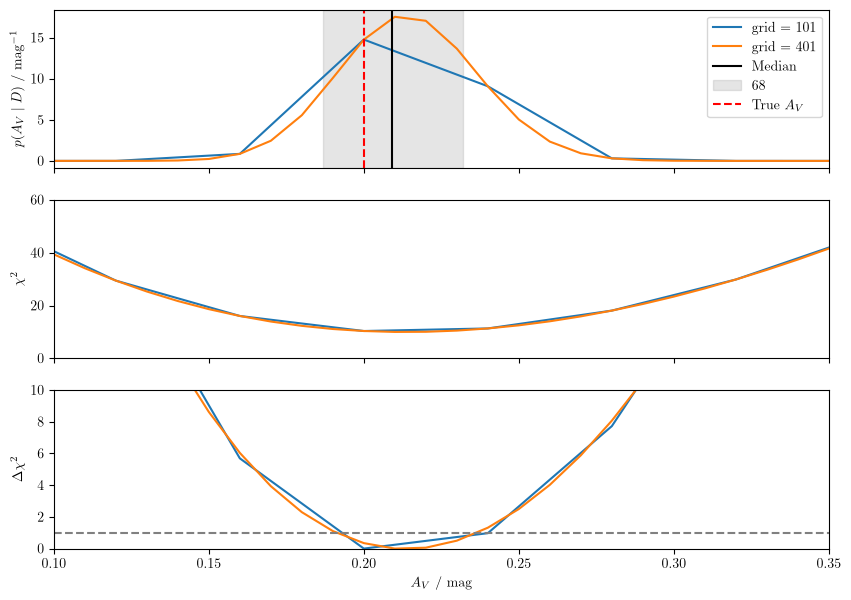

In [24]:

fig, (ax1, ax2, ax3) = plt.subplots(ncols=1, nrows=3, figsize = (10, 7), sharex = True)
for step in [101, 401]:
    Av_grid, chi2 = results[step]
    post = np.exp(-0.5*(chi2 - chi2.min()))
    post = post / np.trapezoid(post, Av_grid)

    delta = chi2 - chi2.min()
    ax1.plot(Av_grid, post, label = f'grid = {step}')
    ax2.plot(Av_grid, chi2)
    ax3.plot(Av_grid, delta)
ax1.set_xlim(0.1, 0.35)

ax1.set_ylabel(r"$p(A_V \mid D)$ / mag$^{-1}$")

ax2.set_ylim(0, 60)
ax2.set_ylabel(r'$\chi^2$')
ax1.legend()
ax3.axhline(1, color = "grey", linestyle = '--')
ax3.set_ylim(0,10)
ax3.set_xlabel(r"$A_V$ / mag")
ax3.set_ylabel(r"$\Delta\chi^2$")

ax1.axvline(p50, color="black", label="Median")
ax1.axvspan(p16, p84, color="grey", alpha=0.2, label="68% interval")
ax1.axvline(0.2, color="red", linestyle="--", label=r"True $A_V$")

ax1.legend()